**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.


 # 09. Machine Learning with Numerics
This notebook explores machine learning capabilities in Numerics.

## What You'll Learn

- K-Means Clustering (unsupervised)
- Gaussian Mixture Models (probabilistic clustering)
- K-Nearest Neighbors (classification and regression)
- Decision Trees (interpretable models)
- Random Forest (classification and regression)
- Performance comparisons with scikit-learn

## Algorithms Covered

| Algorithm | Type | Use Case |
|-----------|------|----------|
| **K-Means** | Clustering | Fast, hard cluster assignments |
| **GMM** | Clustering | Probabilistic, soft assignments, non-spherical clusters |
| **KNN** | Instance-based | Simple classification/regression |
| **Decision Trees** | Tree-based | Interpretable, handles non-linearity |
| **Random Forest** | Ensemble | Classification/regression with feature importance |


## Performance Metrics

- **Accuracy**: fraction of correct class predictions.
- **F1 Score**: harmonic mean of precision and recall.
- **Confusion Matrix**: table of true vs predicted class counts.
- **RMSE**: square root of mean squared error; average prediction error magnitude.
- **R²**: proportion of variance explained by the model (regression).
- **Adjusted Rand Index (ARI)**: clustering similarity corrected for chance.

## Setup

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# sklearn datasets (instead of having to generate synthetic data)
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, adjusted_rand_score  # NOTE: no Numerics equivalents for these yet
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans as SKLearnKMeans
from scipy.optimize import linear_sum_assignment

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.MachineLearning import KMeans, RandomForest, GaussianMixtureModel, KNearestNeighbors, DecisionTree
from Numerics.Mathematics.LinearAlgebra import Matrix, Vector
from Numerics.Data.Statistics import GoodnessOfFit
from helper_functions import convert_to_dotnet_array, convert_to_dotnet_2d_array
from System import Array, Double, String
from System.Collections.Generic import List

print("✓ Setup complete")

✓ Setup complete


## Helper Functions
We define a helper function to time our methods.


In [2]:
def timed_fit(train_callable):
    t0 = time.perf_counter()
    train_callable()
    return (time.perf_counter() - t0) * 1000.0  # ms

print("✓ Helper ready")

✓ Helper ready


## K-Means Clustering
K-Means [[1]](#1), [[2]](#2) is an unsupervised learning algorithm that partitions data into K clusters.  It works best when clusters are roughly compact and spherical.
 The $k$-means algorithm seeks to minimize the within-cluster sum of squares (WCSS) objective function:

$$
J = \sum_{k=1}^{K} \sum_{\mathbf{x} \in C_k} \|\mathbf{x} - \boldsymbol{\mu}_k\|^2
$$

where $C_k$ is the set of observations assigned to cluster $k$ and $\boldsymbol{\mu}_k$ is the centroid (mean) of cluster $k$.

### K-Means++ initialization 
The default initialization method selects initial centroids that are well-separated. The first centroid is chosen uniformly at random. Each subsequent centroid is selected with probability proportional to $D(\mathbf{x})^2$, where $D(\mathbf{x})$ is the Euclidean distance from $\mathbf{x}$ to the nearest already-chosen centroid. This initialization significantly reduces the chance of poor convergence compared to random initialization. The algorithm converges when the cluster labels do not change between iterations, or when `MaxIterations` (default 1000) is reached.

### Example 1: Iris Dataset
The famous Iris dataset contains measurements of 150 iris flowers from 3 species. Let's take a look at how we can classify these 3 species.


In [3]:
# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

features_list = List[Array[Double]]()
for feature_idx in range(X_iris.shape[1]):
    feature_array = Array[Double]([float(x) for x in X_iris[:, feature_idx]])
    features_list.Add(feature_array)

features = Matrix(features_list)
features.Header = Array[String](["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"])

data_tbl = pd.DataFrame({'Metric':['Samples','Features','True species classes'],'Value':
                         [features.NumberOfColumns,features.NumberOfRows,len(set(y_iris))]})
print('Iris dataset summary')
display(data_tbl)

Iris dataset summary


,Metric,Value
0,Samples,4
1,Features,150
2,True species classes,3


We'll cluster the Iris data into 3 groups (matching the 3 species).


In [4]:
# Create and train K-Means model
n_clusters = 3
kmeans = KMeans(features, n_clusters)
kmeans.Train(12345)

# Pull labels
labels = list(kmeans.Labels)
# Count number of observations in each label (i.e cluster)
cluster_counts = [labels.count(i) for i in range(n_clusters)]

meta_tbl = pd.DataFrame({'Metric':['Number of clusters','Converged'],'Value':[n_clusters,'Yes']})
size_tbl = pd.DataFrame({'Cluster':[f'Cluster {i}' for i in range(n_clusters)], 'Samples':cluster_counts})
centers_tbl = pd.DataFrame({'Cluster': list(range(n_clusters)), 'Sepal L':[kmeans.Means[i,0] for i in range(n_clusters)], 'Sepal W':[kmeans.Means[i,1] for i in range(n_clusters)], 'Petal L':[kmeans.Means[i,2] for i in range(n_clusters)], 'Petal W':[kmeans.Means[i,3] for i in range(n_clusters)]})

print('K-Means summary')
display(meta_tbl)
print('Cluster sizes')
display(size_tbl)
print('Cluster centers')
display(centers_tbl.round(3))

K-Means summary


,Metric,Value
0,Number of clusters,3
1,Converged,Yes


Cluster sizes


,Cluster,Samples
0,Cluster 0,62
1,Cluster 1,38
2,Cluster 2,50


Cluster centers


,Cluster,Sepal L,Sepal W,Petal L,Petal W
0,0,5.902,2.748,4.394,1.434
1,1,6.850,3.074,5.742,2.071
2,2,5.006,3.428,1.462,0.246


#### Visualize Clusters

Let's plot the clusters in 2D using the first two principal components.


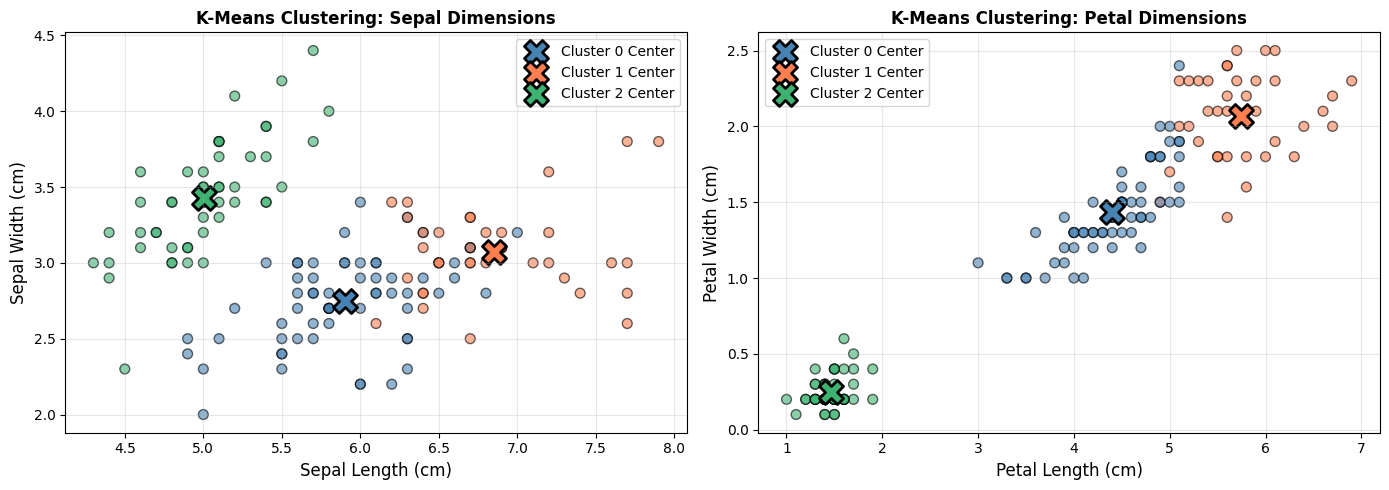

In [5]:
# Extract data for plotting
sepal_l = np.array(features_list[0])
sepal_w = np.array(features_list[1])
petal_l = np.array(features_list[2])
petal_w = np.array(features_list[3])

# Create scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define colors for clusters
colors = ['steelblue', 'coral', 'mediumseagreen']
# Assign cluster color to each point
cluster_colors = [colors[label] for label in labels]

# Plot 1: Sepal dimensions
axes[0].scatter(sepal_l, sepal_w, c=cluster_colors, alpha=0.6, s=50, edgecolor='black')
for i in range(n_clusters):
    axes[0].scatter(kmeans.Means[i, 0], kmeans.Means[i, 1], 
                   c=colors[i], marker='X', s=300, edgecolor='black', linewidth=2,
                   label=f'Cluster {i} Center')
axes[0].set_xlabel('Sepal Length (cm)', fontsize=12)
axes[0].set_ylabel('Sepal Width (cm)', fontsize=12)
axes[0].set_title('K-Means Clustering: Sepal Dimensions', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Petal dimensions
axes[1].scatter(petal_l, petal_w, c=cluster_colors, alpha=0.6, s=50, edgecolor='black')
for i in range(n_clusters):
    axes[1].scatter(kmeans.Means[i, 2], kmeans.Means[i, 3], 
                   c=colors[i], marker='X', s=300, edgecolor='black', linewidth=2,
                   label=f'Cluster {i} Center')
axes[1].set_xlabel('Petal Length (cm)', fontsize=12)
axes[1].set_ylabel('Petal Width (cm)', fontsize=12)
axes[1].set_title('K-Means Clustering: Petal Dimensions', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Performance Comparison: Numerics vs Scikit-Learn

Let's compare speed and results with scikit-learn's K-Means [[1]](#1), [[2]](#2) on the Iris dataset.


In [6]:
start = time.perf_counter()
kmeans_numerics = KMeans(features, n_clusters)
kmeans_numerics.Train(12345)
time_numerics = time.perf_counter() - start

X = pd.DataFrame({
    'Sepal Length': sepal_l,
    'Sepal Width': sepal_w,
    'Petal Length': petal_l,
    'Petal Width': petal_w
})

start = time.perf_counter()
kmeans_sklearn = SKLearnKMeans(n_clusters=n_clusters, init="k-means++", n_init=1, max_iter=1000, random_state=12345)
kmeans_sklearn.fit(X)
time_sklearn = time.perf_counter() - start

numerics_centers = np.array([[kmeans_numerics.Means[i, j] for j in range(4)] for i in range(n_clusters)])
sklearn_centers = kmeans_sklearn.cluster_centers_

# Match cluster labels -- Numerics and sklearn return labels in a random order (so they will not automatically match)
# Sqaured Euclidean distance between each pair of centers'
cost_matrix = np.linalg.norm(numerics_centers[:, None, :] - sklearn_centers[None, :, :], axis=2)
# rowIndex = Numerics cluster index, colIndex = sklearn cluster index
row_ind, col_ind = linear_sum_assignment(cost_matrix)

numerics_labels = list(kmeans_numerics.Labels)
sklearn_labels = kmeans_sklearn.labels_
numerics_counts = [numerics_labels.count(i) for i in range(n_clusters)]
# Remap sklearn labels into Numerics order
sklearn_counts_matched = [sum(sklearn_labels == col_ind[i]) for i in range(n_clusters)]

perf_df = pd.DataFrame([
    ['KMeans', 'Numerics', time_numerics*1000],
    ['KMeans', 'scikit-learn', time_sklearn*1000],
], columns=['Model', 'Library', 'Runtime_ms'])
display(perf_df)
print(f"Speedup: Numerics is {time_sklearn/time_numerics:.2f}x faster than scikit-learn")

counts_df = pd.DataFrame({
    'Cluster': list(range(n_clusters)),
    'Numerics': numerics_counts,
    'Scikit-Learn': sklearn_counts_matched
})
display(counts_df)

center_dist = []
sklearn_centers_ordered = sklearn_centers[col_ind]
for i in range(n_clusters):
    distance = np.linalg.norm(numerics_centers[i] - sklearn_centers_ordered[i])
    center_dist.append(distance)
dist_df = pd.DataFrame({'Cluster': list(range(n_clusters)), 'CenterDistance': center_dist})
display(dist_df)

,Model,Library,Runtime_ms
0,KMeans,Numerics,1.6793
1,KMeans,scikit-learn,1809.7117


Speedup: Numerics is 1077.66x faster than scikit-learn


,Cluster,Numerics,Scikit-Learn
0,0,62,61
1,1,38,39
2,2,50,50


,Cluster,CenterDistance
0,0,2.011435e-02
1,1,3.217668e-02
2,2,1.408988e-15


### Example 2: Clustering Generated Data

Let's test K-Means on synthetic data with known clusters.


Running K-Means on synthetic data...


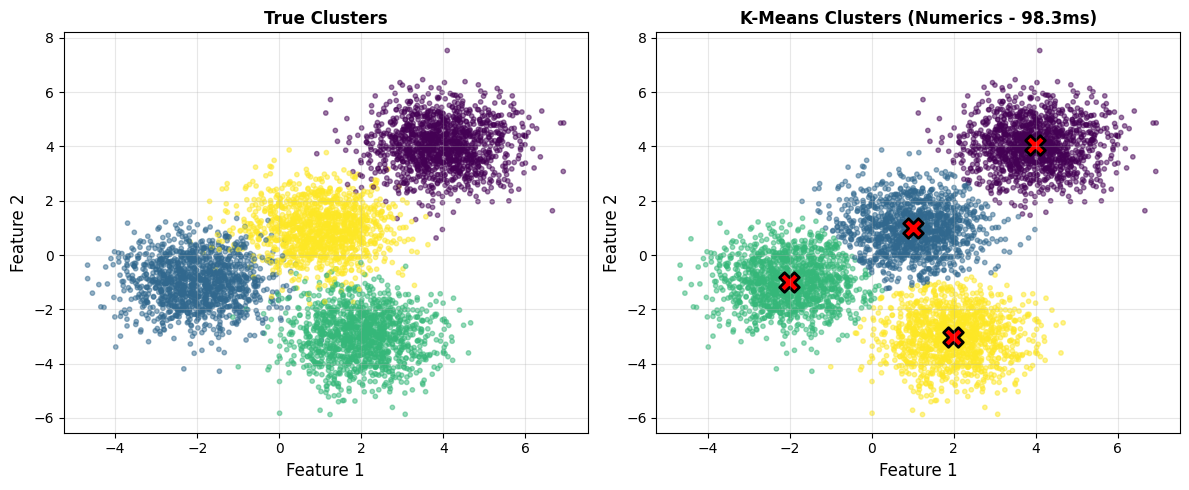


Successfully clustered 5000 points into 4 clusters
Runtime: 98.26 ms


In [7]:
# Generate synthetic data with 4 clear clusters
np.random.seed(12345)
X, y_true = make_blobs(n_samples=5000, centers=[[4,4], [-2, -1], [2, -3], [1, 1]], 
                        cluster_std=0.90)

# Convert to Numerics format (transpose: features as rows)
X_T = X.T
features_list_synthetic = List[Array[Double]]()
for row in X_T:
    net_row = Array[Double]([float(v) for v in row])
    features_list_synthetic.Add(net_row)

features_synthetic = Matrix(features_list_synthetic)

# Run Numerics K-Means
print("Running K-Means on synthetic data...")
start = time.perf_counter()
kmeans_synthetic = KMeans(features_synthetic, 4)
kmeans_synthetic.Train(12345)
time_numerics_synth = time.perf_counter() - start

labels_numerics = list(kmeans_synthetic.Labels)

# Visualize results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.5, s=10)
plt.title('True Clusters', fontsize=12, fontweight='bold')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels_numerics, cmap='viridis', alpha=0.5, s=10)
for i in range(4):
    plt.scatter(kmeans_synthetic.Means[i, 0], kmeans_synthetic.Means[i, 1],
                marker='X', s=200, c='red', edgecolor='black', linewidth=2)
plt.title(f'K-Means Clusters (Numerics - {time_numerics_synth*1000:.1f}ms)', 
            fontsize=12, fontweight='bold')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSuccessfully clustered {len(labels_numerics)} points into 4 clusters")
print(f"Runtime: {time_numerics_synth*1000:.2f} ms")


## Gaussian Mixture Models
A Gaussian Mixture Model represents the data as a mixture of $K$ multivariate Gaussian components. The probability density function of the mixture is:

$$
p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)
$$

where $\pi_k$ are the mixing weights (with $\sum_k \pi_k = 1$ and $\pi_k \geq 0$), $\boldsymbol{\mu}_k$ is the mean vector, and $\boldsymbol{\Sigma}_k$ is the covariance matrix of component $k$. When all covariance matrices are constrained to $\sigma^2 \mathbf{I}$ and $\sigma^2 \to 0$, the soft responsibilities $r_{ik}$ converge to hard 0/1 assignments, recovering the K-Means solution. The parameters are estimated by maximizing the log-likelihood using the EM algorithm, initialized from a K-Means solution with equal weights and near-identity covariance matrices.

Advantages over K-Means:
- Soft clustering (probabilistic assignments)
- Flexible cluster shapes (elliptical vs. spherical)
- Provides uncertainty quantification
- Can model overlapping clusters


GMM summary


,Metric,Value
0,ARI,0.941012
1,Iterations,65.000000
2,Log-likelihood,140.370638
3,Runtime (ms),11.821900


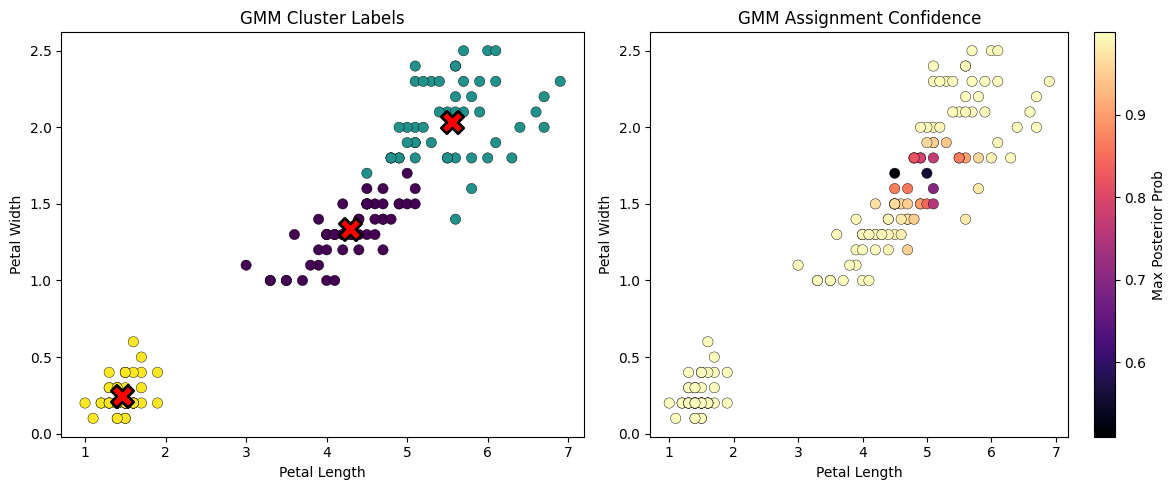

In [8]:
# Use iris dataset
X_gmm = X_iris[:, [2, 3]]
# Create mixture model
gmm = GaussianMixtureModel(convert_to_dotnet_2d_array(X_gmm), n_clusters)
gmm.MaxIterations = 500
gmm.Tolerance = 1e-8

# Fit mixture model and pull out labels (i.e. clusters)
gmm_ms = timed_fit(lambda: gmm.Train(12345, True))
labels_gmm = np.array(list(gmm.Labels), dtype=int)
# sklearn Rand index adjusted for chance (computes similarity measure between two clusterings)
ari_gmm = adjusted_rand_score(y_iris, labels_gmm)  # NOTE: Numerics has no ARI equivalent yet

n, k = X_gmm.shape[0], 3
# Get likelihood for each data point(row) and for each cluster (column)
probs = np.array([[gmm.LikelihoodMatrix[i, j] for j in range(k)] for i in range(n)])
confidence = probs.max(axis=1)

gmm_tbl = pd.DataFrame({'Metric':['ARI','Iterations','Log-likelihood','Runtime (ms)'],'Value':
                        [ari_gmm,gmm.Iterations,gmm.LogLikelihood,gmm_ms]})
print('GMM summary')
display(gmm_tbl)

# Visualize the clusters
fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].scatter(X_gmm[:,0], X_gmm[:,1], c=labels_gmm, cmap='viridis', s=55, edgecolor='black', linewidth=0.3)
for i in range(3):
    ax[0].scatter(gmm.Means[i,0], gmm.Means[i,1], marker='X', s=260, c='red', edgecolor='black', linewidth=2)
ax[0].set_title('GMM Cluster Labels'); ax[0].set_xlabel('Petal Length'); ax[0].set_ylabel('Petal Width')

# Assignment confidence
sc = ax[1].scatter(X_gmm[:,0], X_gmm[:,1], c=confidence, cmap='magma', s=55, edgecolor='black', linewidth=0.3)
ax[1].set_title('GMM Assignment Confidence'); ax[1].set_xlabel('Petal Length'); ax[1].set_ylabel('Petal Width')
plt.colorbar(sc, ax=ax[1], label='Max Posterior Prob')
plt.tight_layout(); plt.show()

## K-Nearest Neighbors (KNN) 
KNN is a lazy learning algorithm that stores the training data and defers computation until prediction time [[3]](#3). Given a new input $\mathbf{x}$, the algorithm finds the $k$ nearest training observations using the Euclidean distance:

$$
d(\mathbf{x}, \mathbf{x}_i) = \sqrt{\sum_{j=1}^{p} (x_j - x_{ij})^2}
$$
where $p$ is the number of features. As the number of features $p$ grows, Euclidean distances become increasingly uniform, degrading the discriminative power of nearest neighbor methods. Feature scaling (normalization) is critical because KNN is sensitive to the relative magnitudes of features [[3]](#3).

The choice of $k$ controls the bias-variance tradeoff. A small $k$ produces a flexible model sensitive to noise, while a large $k$ produces smoother decision boundaries at the cost of increased bias. A common rule of thumb is $k = \sqrt{n}$, where $n$ is the number of training observations, though cross-validation is preferred for rigorous selection.

### Classification
For classification, the prediction is determined by majority vote among the $k$ nearest neighbors: the class that appears most frequently is assigned to the new observation.


KNN classification summary


,Metric,Value
0,Accuracy,97.777778
1,F1,0.971429
2,Runtime (ms),7.745500


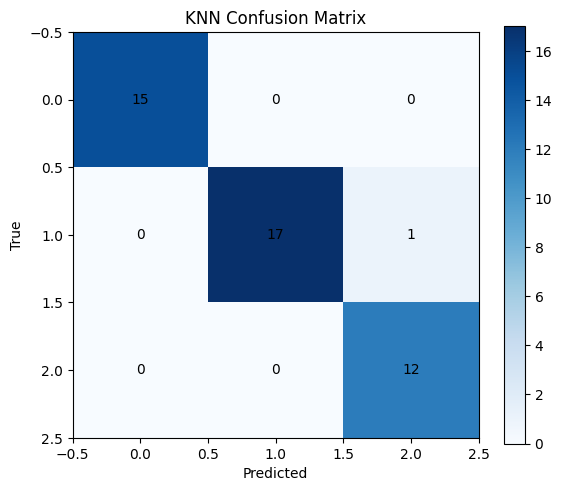

In [9]:
wine = load_wine()
X, y = wine.data, wine.target.astype(float)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Standardize by removing the mean and scaling to unit varaiance
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train_net = convert_to_dotnet_2d_array(X_train_s)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test_s)

# Initialize
knn_clf = KNearestNeighbors(Matrix(X_train_net), Vector(y_train_net), 7)
knn_clf.IsRegression = False

# Make predictions!
knn_clf_ms = timed_fit(lambda: knn_clf.Predict(Matrix(X_test_net)))
y_pred = np.array(list(knn_clf.Predict(Matrix(X_test_net))), dtype=int)

# Performance metrics
y_test_gof = convert_to_dotnet_array(y_test.astype(float))
y_pred_gof = convert_to_dotnet_array(y_pred.astype(float))
acc = GoodnessOfFit.Accuracy(y_test_gof, y_pred_gof)
f1 = GoodnessOfFit.F1Score(y_test_gof, y_pred_gof)
cm = confusion_matrix(y_test, y_pred)  # Numerics has no confusion matrix yet

knn_cls_df = pd.DataFrame({'Metric':['Accuracy','F1','Runtime (ms)'],'Value':[acc, f1, knn_clf_ms]})
print('KNN classification summary')
display(knn_cls_df)

# The diagonal represent correct classifications
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.colorbar(); plt.tight_layout(); plt.show()

### Regression
For regression, the prediction is an inverse distance weighted average of the $k$ nearest neighbors:

$$
\hat{y} = \frac{\sum_{i=1}^{k} w_i \cdot y_i}{\sum_{i=1}^{k} w_i}, \quad w_i = \frac{1}{d(\mathbf{x}, \mathbf{x}_i)^2}
$$

If the distance to a neighbor is exactly zero (i.e., the query point coincides with a training point), that neighbor receives a weight of $w_i = 1$ and all other weights are set accordingly.


KNN Regression Summary


,Metric,Value
0,RMSE,54.898579
1,R²,0.458421
2,Runtime (ms),16.164400


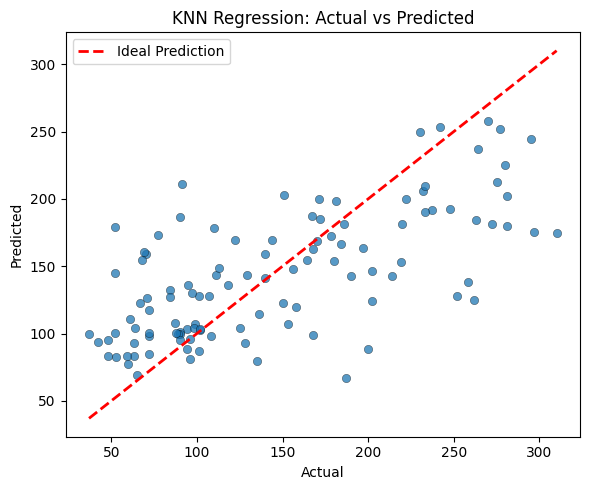

In [10]:
diab = load_diabetes()
X, y = diab.data, diab.target.astype(float)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize by removing the mean and scaling to unit varaiance
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train_net = convert_to_dotnet_2d_array(X_train_s)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test_s)

# Initialize
knn_reg = KNearestNeighbors(Matrix(X_train_net), Vector(y_train_net), 9)
knn_reg.IsRegression = True

knn_reg_ms = timed_fit(lambda: knn_reg.Predict(Matrix(X_test_net)))
y_pred = np.array(list(knn_reg.Predict(Matrix(X_test_net))), dtype=float)
# Performace metrics
y_test_gof = convert_to_dotnet_array(y_test.astype(float))
y_pred_gof = convert_to_dotnet_array(y_pred.astype(float))
rmse = np.sqrt(GoodnessOfFit.MSE(y_test_gof, y_pred_gof))
r2 = GoodnessOfFit.RSquared(y_test_gof, y_pred_gof)

knn_rg_df = pd.DataFrame({'Metric':['RMSE','R²','Runtime (ms)'],'Value':[rmse, r2, knn_reg_ms]})
print('KNN Regression Summary')
display(knn_rg_df)

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.75, edgecolor='black', linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Ideal Prediction')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('KNN Regression: Actual vs Predicted'); plt.legend(); plt.tight_layout(); plt.show()

## Decision Trees
Decision Trees [[4]](#4) split feature space into human-readable rules, making them highly interpretable. They can model nonlinear boundaries but may overfit without depth/split controls. Classification and regression trees recursively partition the feature space using binary splits of the form $x_j\le t$ (left child) and $x_j>t$ (right child), where $x_j$ is a feature and $t$ is a threshold. At each internal node, the algorithm selects the feature and threshold that maximize a splitting criterion.

For regression, the prediction is the mean of the training observations at the leaf: $\hat{y} = \bar{y}_{\text{leaf}}$. For classification, the prediction is the most frequent class among the leaf observations.

Tree growth stops when any of the following conditions is met: the maximum depth (`MaxDepth`, default 100) is reached, the number of observations at a node falls below `MinimumSplitSize` (default 2), or all observations at a node belong to the same class.

### Classification
Uses information gain based on Shannon entropy. The entropy of a node $S$ with $C$ classes is:

$$
H(S) = -\sum_{c=1}^{C} p_c \log(p_c)
$$

where $p_c$ is the proportion of observations belonging to class $c$. The information gain from splitting node $S$ into children $S_L$ and $S_R$ is:

$$
\text{IG}(S, S_L, S_R) = H(S) - \frac{n_L}{n_S} H(S_L) - \frac{n_R}{n_S} H(S_R)
$$

where $n_L$, $n_R$, and $n_S$ are the number of observations in the left child, right child, and parent node, respectively.




Decision Tree Classification Summary


,Metric,Value
0,Accuracy,92.307692
1,F1,0.937143
2,Runtime (ms),10610.641000


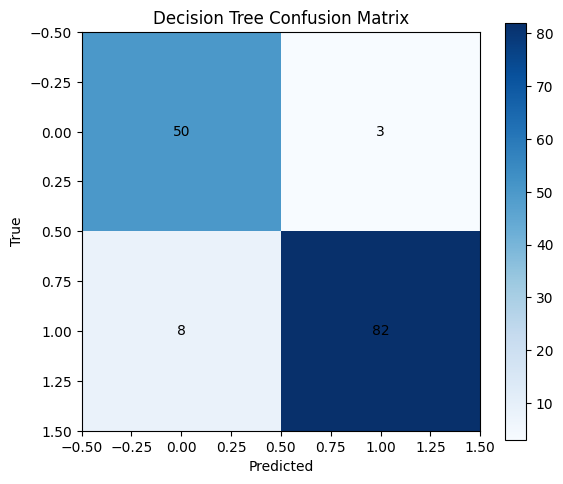

In [11]:
bc = load_breast_cancer()
X, y = bc.data, bc.target.astype(float)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test)

# Intializie
dt_clf = DecisionTree(Matrix(X_train_net), Vector(y_train_net), 12345)
dt_clf.IsRegression = False
# Depth control is very important for decision trees
dt_clf.MaxDepth = 8
dt_clf.MinimumSplitSize = 5
dt_clf.Features = X_train.shape[1]

dt_clf_ms = timed_fit(lambda: dt_clf.Train())
y_pred = np.array(list(dt_clf.Predict(Matrix(X_test_net))), dtype=int)

# Performance metrics
y_test_gof = convert_to_dotnet_array(y_test.astype(float))
y_pred_gof = convert_to_dotnet_array(y_pred.astype(float))
acc = GoodnessOfFit.Accuracy(y_test_gof, y_pred_gof)
f1 = GoodnessOfFit.F1Score(y_test_gof, y_pred_gof)
cm = confusion_matrix(y_test.astype(int), y_pred)  # Numerics has no confusion matrix yet

dt_cls_df = pd.DataFrame({'Metric':['Accuracy','F1','Runtime (ms)'],'Value':[acc,f1,dt_clf_ms]})
print('Decision Tree Classification Summary')
display(dt_cls_df)

# The diagonal represents correct classifications
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.colorbar(); plt.tight_layout(); plt.show()

### Regression
Use variance reduction. The population variance of a node $S$ is:

$$
\text{Var}(S) = \frac{1}{n_S} \sum_{i \in S} (y_i - \bar{y}_S)^2
$$

The variance reduction from a split is:

$$
\text{VR}(S, S_L, S_R) = \text{Var}(S) - \frac{n_L}{n_S} \text{Var}(S_L) - \frac{n_R}{n_S} \text{Var}(S_R)
$$


Decision Tree Regression Summary


,Metric,Value
0,RMSE,71.132731
1,R²,0.266772
2,Runtime (ms),76.166300


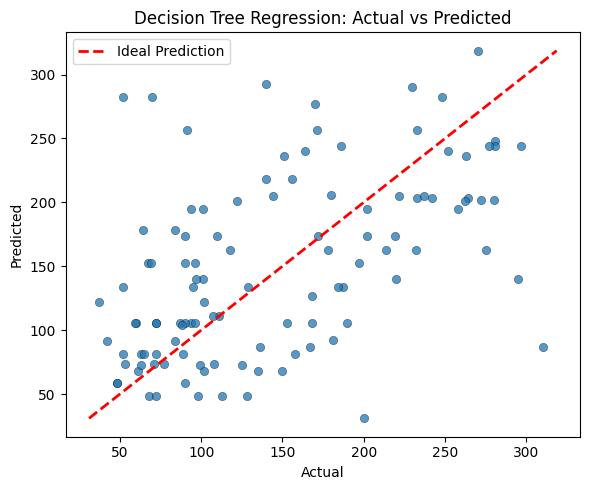

In [12]:
X, y = diab.data, diab.target.astype(float)
# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test)

dt_reg = DecisionTree(Matrix(X_train_net), Vector(y_train_net), 12345)
# We have to ensure the Decision Tree regressor knows it's a regression task (not classification) since it can do both
dt_reg.IsRegression = True
# Max Depth helps control overfitting
dt_reg.MaxDepth = 8
# Minimum split size also helps control overfitting by preventing splits that are too small to be meaningful, and can speed up training
dt_reg.MinimumSplitSize = 8
dt_reg.Features = X_train.shape[1]

dt_reg_ms = timed_fit(lambda: dt_reg.Train())
y_pred = np.array(list(dt_reg.Predict(Matrix(X_test_net))), dtype=float)

# Performace metrics
y_test_gof = convert_to_dotnet_array(y_test.astype(float))
y_pred_gof = convert_to_dotnet_array(y_pred.astype(float))
rmse = np.sqrt(GoodnessOfFit.MSE(y_test_gof, y_pred_gof))
r2 = GoodnessOfFit.RSquared(y_test_gof, y_pred_gof)

dt_rg_df = pd.DataFrame({'Metric':['RMSE','R²','Runtime (ms)'],'Value':[rmse,r2,dt_reg_ms]})
print('Decision Tree Regression Summary')
display(dt_rg_df)

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.75, edgecolor="black", linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", lw=2, label ="Ideal Prediction")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree Regression: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

## Random Forest
An ensemble of Decision Trees [[4]](#4) for improved accuracy [[5]](#5) [[6]](#6). Random Forests use bootstrap aggregation (bagging) to reduce variance and improve generalization. For each tree $b = 1, \ldots, B$, draw $n$ samples with replacement from the original $n$ observations (default $B = 1000$). On average, each bootstrap sample contains approximately $1 - 1/e \approx 63.2\%$ of the unique training observations, leaving the remainder as out-of-bag (OOB) observations that can be used for validation. At each split within a tree, a random subset of features is considered as split candidates. The `Features` property controls the number of candidate features (default $d - 1$, where $d$ is the total number of features). This decorrelates the trees and further reduces variance.

The ensemble prediction for a new input $\mathbf{x}$ aggregates the predictions of all $B$ trees:

$$
\hat{f}_{\text{bag}}(\mathbf{x}) = \frac{1}{B} \sum_{b=1}^{B} \hat{f}_b(\mathbf{x})
$$

For regression, predictions are the direct percentiles across all tree outputs. For classification, predictions are the floor of the percentiles. The `Predict` method returns lower, median, upper, and mean values across the ensemble, providing built-in prediction uncertainty quantification.

Advantages of Random Forests:
- Reduces overfitting compared to single tree
- Provides prediction uncertainty
- Handles missing values well
- Works with mixed feature types

### Classification
Random Forest often gives strong default performance for tabular classification tasks.


Random Forest Classification Summary


,Metric,Value
0,Accuracy,95.104895
1,F1,0.961326
2,Runtime (s),8.353306


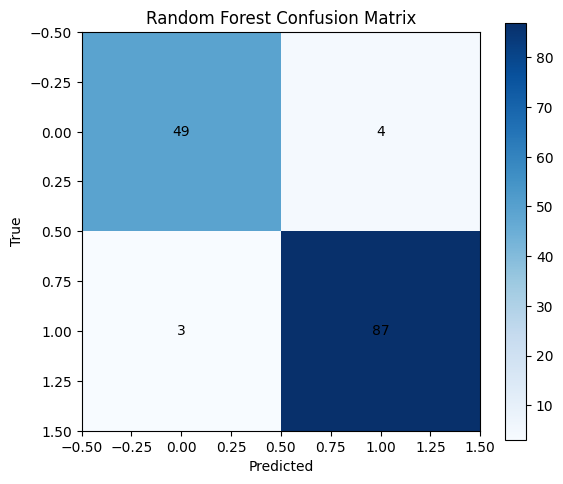

In [13]:
X, y = bc.data, bc.target.astype(float)
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test)

# Initialize
rf_clf = RandomForest(Matrix(X_train_net), Vector(y_train_net), 12345)
rf_clf.IsRegression = False
# Set tree count to match default scikit-learn settings
rf_clf.NumberOfTrees = 100
rf_clf.MaxDepth = 20
rf_clf.MinimumSplitSize = 2
rf_clf.Features = int(np.sqrt(X_train.shape[1]))

rf_clf_ms = timed_fit(lambda: rf_clf.Train())
pred_raw = rf_clf.Predict(Matrix(X_test_net))
n = pred_raw.GetLength(0)
y_pred = np.array([pred_raw[i, 1] for i in range(n)], dtype=float)

# Performace metrics
y_test_gof = convert_to_dotnet_array(y_test.astype(float))
y_pred_gof = convert_to_dotnet_array(y_pred.astype(float))
acc = GoodnessOfFit.Accuracy(y_test_gof, y_pred_gof)
f1 = GoodnessOfFit.F1Score(y_test_gof, y_pred_gof)
cm = confusion_matrix(y_test.astype(int), y_pred)  # Numerics has no confusion matrix yet

rf_cls_df = pd.DataFrame({'Metric':['Accuracy','F1','Runtime (s)'],'Value':[acc,f1,rf_clf_ms/1000]})
print('Random Forest Classification Summary')
display(rf_cls_df)

# The diagonal shows correct classifications
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.colorbar(); plt.tight_layout(); plt.show()

### Regression
In regression mode, Random Forest averages predictions across many trees, which generally improves stability and predictive power over a single tree [[5]](#5). It's a strong baseline for nonlinear tabular regression.

Random Forest Classification Summary


,Metric,Value
0,RMSE,53.032470
1,R²,0.495277
2,Runtime (ms),428.089600


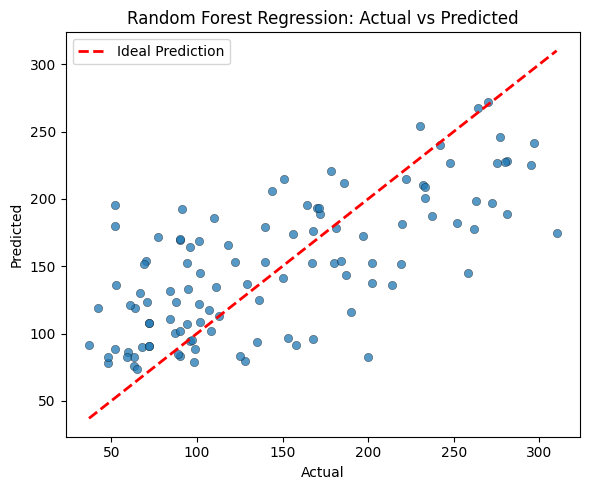

In [14]:
X, y = diab.data, diab.target.astype(float)
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train)
X_test_net = convert_to_dotnet_2d_array(X_test)

rf_reg = RandomForest(X_train_net, y_train_net, 12345)
# We have to ensure the Random Forest regressor knows it's a regression task (not classification) since it can do both
rf_reg.IsRegression = True
# More trees generally improves accuracy but increases runtime, 1000 is used here to match Numerics default and scikit-learn settings
# Set tree count to match defau;t scikit-learn settings
rf_reg.NumberOfTrees = 100
# Max Depth helps control overfitting
# Random Forests can often benefit from deeper trees than single Decision Trees since they average many trees
rf_reg.MaxDepth = 20
# Minimum split size also helps control overfitting by preventing splits that are too small to be meaningful, and can speed up training
rf_reg.MinimumSplitSize = 2
rf_reg.Features = max(1, X_train.shape[1] // 3)

rf_reg_ms = timed_fit(lambda: rf_reg.Train())

pred_raw = rf_reg.Predict(Matrix(X_test_net))
n = pred_raw.GetLength(0)
y_pred = np.array([pred_raw[i, 3] for i in range(n)], dtype=float)

# Performance metrics
y_test_gof = convert_to_dotnet_array(y_test.astype(float))
y_pred_gof = convert_to_dotnet_array(y_pred.astype(float))
rmse = np.sqrt(GoodnessOfFit.MSE(y_test_gof, y_pred_gof))
r2 = GoodnessOfFit.RSquared(y_test_gof, y_pred_gof)

rf_reg_df = pd.DataFrame({'Metric':['RMSE','R²','Runtime (ms)'],'Value':[rmse,r2,rf_reg_ms]})
print('Random Forest Classification Summary')
display(rf_reg_df)

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.75, edgecolor="black", linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", lw=2, label ="Ideal Prediction")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Regression: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

## Numerics vs scikit-learn Benchmarks
Now we compare our radom forest methods from Numerics with Python's implementations in the "scikit-learn" package. We want to look at differences in runtimes and accuracy between the two.


In [15]:
benchmark_rows = []

# Classification benchmark
X, y = bc.data, bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train.astype(float))
X_test_net = convert_to_dotnet_2d_array(X_test)

rf_num = RandomForest(X_train_net, y_train_net, 12345)
rf_num.IsRegression = False
# Set tree count to match Python's default scikit-learn settings
rf_num.NumberOfTrees = 100
rf_num.Features = int(np.sqrt(X_train.shape[1]))

t_num = timed_fit(lambda: rf_num.Train())
pred_raw = rf_num.Predict(X_test_net)
n = pred_raw.GetLength(0)
y_num = np.array([pred_raw[i, 3] for i in range(n)], dtype=float)
y_num = np.rint(y_num).astype(int)
y_test_gof = convert_to_dotnet_array(y_test.astype(float))
y_num_gof = convert_to_dotnet_array(y_num.astype(float))
acc_num = GoodnessOfFit.Accuracy(y_test_gof, y_num_gof)

t0 = time.perf_counter()
rf_sk = RandomForestClassifier(n_estimators=1000, max_depth=100, random_state=12345, n_jobs=-1)
rf_sk.fit(X_train, y_train)
t_sk = (time.perf_counter() - t0) * 1000
y_sk = rf_sk.predict(X_test).astype(float)
acc_sk = GoodnessOfFit.Accuracy(y_test_gof, convert_to_dotnet_array(y_sk))

benchmark_rows.append(['RF Classifier', 'Numerics', t_num, acc_num])
benchmark_rows.append(['RF Classifier', 'scikit-learn', t_sk, acc_sk])

# Regression benchmark
X, y = diab.data, diab.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train_net = convert_to_dotnet_2d_array(X_train)
y_train_net = convert_to_dotnet_array(y_train.astype(float))
X_test_net = convert_to_dotnet_2d_array(X_test)

rf_num_r = RandomForest(X_train_net, y_train_net, 12345)
rf_num_r.IsRegression = True
# Set tree count to match Python'set default scikit-learn settings
rf_num_r.NumberOfTrees = 100
rf_num_r.Features = max(1, X_train.shape[1] // 3)

t_num_r = timed_fit(lambda: rf_num_r.Train())
pred_raw = rf_num_r.Predict(X_test_net)
n = pred_raw.GetLength(0)
pred_num_r = np.array([pred_raw[i, 3] for i in range(n)], dtype=float)
y_test_gof = convert_to_dotnet_array(y_test.astype(float))
pred_num_gof = convert_to_dotnet_array(pred_num_r.astype(float))
r2_num = GoodnessOfFit.RSquared(y_test_gof, pred_num_gof)

t0 = time.perf_counter()
rf_sk_r = RandomForestRegressor(n_estimators=1000, max_depth=100, random_state=12345, n_jobs=-1)
rf_sk_r.fit(X_train, y_train)
t_sk_r = (time.perf_counter() - t0) * 1000
y_sk_r = rf_sk_r.predict(X_test).astype(float)
r2_sk = GoodnessOfFit.RSquared(y_test_gof, convert_to_dotnet_array(y_sk_r))

benchmark_rows.append(['RF Regressor', 'Numerics', t_num_r, r2_num])
benchmark_rows.append(['RF Regressor', 'scikit-learn', t_sk_r, r2_sk])

bench_df = pd.DataFrame(benchmark_rows, columns=['Model', 'Library', 'Runtime_ms', 'Score'])
display(bench_df)

,Model,Library,Runtime_ms,Score
0,RF Classifier,Numerics,8554.8704,58.041958
1,RF Classifier,scikit-learn,1305.6241,95.804196
2,RF Regressor,Numerics,460.2014,0.496525
3,RF Regressor,scikit-learn,834.4519,0.478203


## Summary
You implemented and evaluated:

$\checkmark$ K-Means clustering       
$\checkmark$ Gaussian Mixture Models      
$\checkmark$ K-Nearest Neighbors      
$\checkmark$ Decision Trees      
$\checkmark$ Random Forests (classification and regression)       

Primary evaluation metrics in this notebook include accuracy (classification), RMSE/R² (regression), and ARI-like clustering diagnostics where applicable.

## Exercise
1. Fit K Means with k=2.6 and plot inertia.
2. Compare GMM  with K-Means.
3. Which method clusters Iris best?

## References

<a id="1">[1]</a> J. MacQueen, "Some methods for classification and analysis of multivariate observations," *Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability*, vol. 1, pp. 281-297, 1967.

<a id="2">[2]</a> D. Arthur and S. Vassilvitskii, "k-means++: The advantages of careful seeding," *Proceedings of the 18th Annual ACM-SIAM Symposium on Discrete Algorithms*, pp. 1027-1035, 2007.

<a id="3">[3]</a> T. Cover and P. Hart, "Nearest neighbor pattern classification," *IEEE Transactions on Information Theory*, vol. 13, no. 1, pp. 21-27, 1967.

<a id="4">[4]</a> L. Breiman, J. H. Friedman, R. A. Olshen, and C. J. Stone, *Classification and Regression Trees*. Wadsworth, 1984.

<a id="5">[5]</a> L. Breiman, "Random forests," *Machine Learning*, vol. 45, no. 1, pp. 5-32, 2001.

<a id="6">[6]</a> T. Hastie, R. Tibshirani, and J. Friedman, *The Elements of Statistical Learning*, 2nd ed. Springer, 2009.
